In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon
import itertools
import sys
sys.path.insert(0, os.path.dirname(os.getcwd()))
import liset_data_reader.lists_sessions as lists_sessions
# Set style
sns.set_style("whitegrid")
# plt.rcParams.update({'font.size': 12})
plt.rcParams['svg.fonttype'] = 'none'
from barplot_brackets import *

In [2]:
# Load Dutta Data
results_path = os.path.join("spikes", "crossval_results.csv")

if os.path.exists(results_path):
    df = pd.read_csv(results_path)
    print(f"Loaded {len(df)} rows from {results_path}")
    
    # Preprocessing
    # Rename ADAPT to Adapt for consistency
    if "ADAPT" in df.columns:
        df.rename(columns={"ADAPT": "Adapt"}, inplace=True)
        
    print("Columns:", df.columns.tolist())
    print("Threshold:", sorted(df["Threshold"].unique()))
    
    display(df.head())
else:
    print(f"File not found: {results_path}. Please run process_live_spikes.py first.")

Loaded 795 rows from spikes\crossval_results.csv
Columns: ['GT', 'Detections', 'Session', 'Threshold', 'TP', 'FP', 'FN', 'Precision', 'Recall', 'F1', 'Mean_Latency', 'Num_Spikes', 'Num_Ripples']
Threshold: [nan]


,GT,Detections,Session,Threshold,TP,FP,FN,Precision,Recall,F1,Mean_Latency,Num_Spikes,Num_Ripples
0,SNN_GT,RippleNet_GT,2025-09-23_15-50-26,NaN,77,114,18,0.403141,0.810526,0.538462,-2.309091,192,95
1,SNN_GT,RippleNet_GT,2025-09-25_12-52-22,NaN,44,640,4,0.064327,0.916667,0.120219,-2.877273,694,48
2,SNN_GT,RippleNet_GT,2025-09-25_11-21-53,NaN,85,224,20,0.275081,0.809524,0.410628,-0.494118,313,105
3,SNN_GT,RippleNet_GT,2025-09-23_16-17-52,NaN,16,76,8,0.173913,0.666667,0.275862,-5.600000,92,24
4,SNN_GT,RippleNet_GT,2025-09-24_15-13-10,NaN,77,27,4,0.740385,0.950617,0.832432,2.150649,104,81


GT,Buzsaki_GT,Dutta_GT,LisetCNN_GT,RipplAI_GT,RippleNet_GT,SNN_GT
Detections,,,,,,
Buzsaki_GT,NaN,0.699115,0.441718,0.585729,0.517986,0.633962
Dutta_GT,0.708134,NaN,0.553763,0.593129,0.468254,0.605634
LisetCNN_GT,0.485714,0.549738,NaN,0.653907,0.375000,0.477064
RipplAI_GT,0.589623,0.596330,0.666667,NaN,0.447689,0.524017
RippleNet_GT,0.529412,0.468254,0.372385,0.447129,NaN,0.528736
SNN_GT,0.645161,0.578616,0.470219,0.533411,0.536122,NaN


GT,B,D,R,C,L,S
Detections,,,,,,
Buzsaki,NaN,0.699115,0.517986,0.441718,0.585729,0.633962
Dutta,0.708134,NaN,0.468254,0.553763,0.593129,0.605634
RippleNet,0.529412,0.468254,NaN,0.372385,0.447129,0.528736
CNN,0.485714,0.549738,0.375000,NaN,0.653907,0.477064
LSTM,0.589623,0.596330,0.447689,0.666667,NaN,0.524017
SNN,0.645161,0.578616,0.536122,0.470219,0.533411,NaN


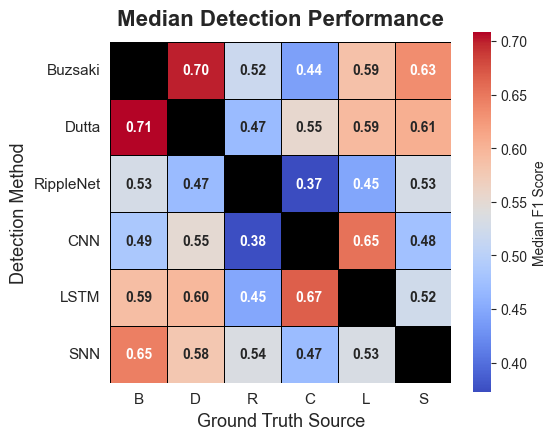

In [16]:
# Create a pivot table: Rows=Detections, Cols=GT, Values=Median F1
heatmap_data = df.pivot_table(index="Detections", columns="GT", values="F1", aggfunc="median")
display(heatmap_data)
# Explicit label maps (robust to input ordering)
gt_label_map = {
    "Buzsaki_GT": "B", "Dutta_GT": "D", "RippleNet_GT": "R", "LisetCNN_GT": "C", "RipplAI_GT": "L", "SNN_GT": "S",
    "B": "B", "D": "D", "R": "R", "C": "C", "L": "L", "S": "S"
}

det_label_map = {
    "Buzsaki_GT": "Buzsaki", "Dutta_GT": "Dutta", "RippleNet_GT": "RippleNet",
    "LisetCNN_GT": "CNN", "RipplAI_GT": "LSTM", "SNN_GT": "SNN"
}

heatmap_data = heatmap_data.rename(columns=gt_label_map, index=det_label_map)

# Force the exact plotting order
gt_order = ["B", "D", "R", "C", "L", "S"]
det_order = ["Buzsaki", "Dutta", "RippleNet", "CNN", "LSTM", "SNN"]
heatmap_data = heatmap_data.reindex(index=det_order, columns=gt_order)

display(heatmap_data)

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.set_facecolor("#000000")

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.6,
    linecolor="black",
    cbar_kws={"label": "Median F1 Score", "shrink": 0.85},
    annot_kws={"size": 10, "weight": "bold"},
    ax=ax
)

ax.set_title("Median Detection Performance", fontsize=16, weight="bold", pad=12)
ax.set_xlabel("Ground Truth Source", fontsize=13)
ax.set_ylabel("Detection Method", fontsize=13)
ax.tick_params(axis="x", labelrotation=0, labelsize=11)
ax.tick_params(axis="y", labelsize=11, labelrotation=0)
ax.set_aspect("equal")
ax.grid(False)

os.makedirs("figures", exist_ok=True)
fig.savefig("figures/dutta_heatmap.svg", bbox_inches="tight", transparent=True, dpi=500)